# AISO v6 — 진짜 삼체: 인력 + 척력 충돌

## v5 실패 원인
전체 합력 → 양수/음수 상쇄 → 합력 ≈ 0 → 아무도 안 움직임

## v6 해결
전체 합산 대신 **가장 강한 인력 1명 + 가장 강한 척력 1명** 동시 적용

```
j_attract = argmax_j c_ij       ← 가장 강하게 당기는 파트너
j_repel   = argmin_j c_ij       ← 가장 강하게 미는 파트너

F = c_attract·(X[j_attract] - X[i])   ← 당김 (+)
  + c_repel  ·(X[j_repel]   - X[i])   ← 밀기 (c_repel < 0이면 자동으로 반대 방향)

X_i' = clip(X_i + α·F, 0, 1)
```

- `c_ij = W_i^T · M · W_j` **핵심 수식 그대로**
- W update: **인력 파트너 타입만** 흡수 (척력은 버림 — 타입 유지)
- M ∈ [-1, 2] 또는 [-2, 2]

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

K        = 30
N_AGENTS = 30
N_ITER   = 100
N_RUNS   = 20
N_TYPES  = 12
BETA     = 0.1
NOISE_SD = 1.0

np.random.seed(42)
print('설정 완료')

설정 완료


In [2]:
# 벤치마크 함수
def make_fn(name, scale, shift, noise=0.0, formula=None):
    def f(x):
        z = x * scale + shift
        return float(formula(z) + np.random.randn()*noise)
    f.__name__ = name + ('_N' if noise else '')
    return f

def make_sphere(n=0.):
    def f(x):
        z=x*10-5; return float(np.sum(z**2)+np.random.randn()*n)
    f.__name__='Sphere'+('_N' if n else ''); return f
def make_rastrigin(n=0.):
    def f(x):
        z=x*10.24-5.12; return float(10*len(z)+np.sum(z**2-10*np.cos(2*np.pi*z))+np.random.randn()*n)
    f.__name__='Rastrigin'+('_N' if n else ''); return f
def make_ackley(n=0.):
    def f(x):
        z=x*64-32; d=len(z)
        return float(-20*np.exp(-0.2*np.sqrt(np.sum(z**2)/d))-np.exp(np.sum(np.cos(2*np.pi*z))/d)+np.e+20+np.random.randn()*n)
    f.__name__='Ackley'+('_N' if n else ''); return f
def make_griewank(n=0.):
    def f(x):
        z=x*1200-600; i=np.arange(1,len(z)+1)
        return float(np.sum(z**2)/4000-np.prod(np.cos(z/np.sqrt(i)))+1+np.random.randn()*n)
    f.__name__='Griewank'+('_N' if n else ''); return f
def make_rosenbrock(n=0.):
    def f(x):
        z=x*4-2; return float(np.sum(100*(z[1:]-z[:-1]**2)**2+(z[:-1]-1)**2)+np.random.randn()*n)
    f.__name__='Rosenbrock'+('_N' if n else ''); return f
def make_levy(n=0.):
    def f(x):
        z=x*20-10; w=1+(z-1)/4
        return float((np.sin(np.pi*w[0]))**2+np.sum((w[:-1]-1)**2*(1+10*np.sin(np.pi*w[:-1]+1)**2))+(w[-1]-1)**2*(1+np.sin(2*np.pi*w[-1])**2)+np.random.randn()*n)
    f.__name__='Levy'+('_N' if n else ''); return f
def make_schwefel(n=0.):
    def f(x):
        z=x*1000-500; return float(418.9829*len(z)-np.sum(z*np.sin(np.sqrt(np.abs(z))))+np.random.randn()*n)
    f.__name__='Schwefel'+('_N' if n else ''); return f
def make_styblinski(n=0.):
    def f(x):
        z=x*10-5; return float(0.5*np.sum(z**4-16*z**2+5*z)+39.166*len(z)+np.random.randn()*n)
    f.__name__='Styblinski'+('_N' if n else ''); return f
def make_zakharov(n=0.):
    def f(x):
        z=x*10-5; i=np.arange(1,len(z)+1); s=np.sum(0.5*i*z)
        return float(np.sum(z**2)+s**2+s**4+np.random.randn()*n)
    f.__name__='Zakharov'+('_N' if n else ''); return f
def make_dixon(n=0.):
    def f(x):
        z=x*20-10; i=np.arange(2,len(z)+1)
        return float((z[0]-1)**2+np.sum(i*(2*z[1:]**2-z[:-1])**2)+np.random.randn()*n)
    f.__name__='Dixon-Price'+('_N' if n else ''); return f

BENCHMARKS = [
    make_sphere(), make_rosenbrock(), make_zakharov(), make_dixon(),
    make_rastrigin(), make_ackley(), make_griewank(), make_levy(),
    make_schwefel(), make_styblinski(),
    make_sphere(NOISE_SD), make_ackley(NOISE_SD), make_rastrigin(NOISE_SD),
]
print(f'벤치마크 {len(BENCHMARKS)}개')

벤치마크 13개


## 알고리즘

In [3]:
# ── PSO 기준선 ────────────────────────────────────────────────
def run_pso(f, K, seed, n_iter=N_ITER, n_agents=N_AGENTS):
    np.random.seed(seed)
    w,c1,c2=0.729,1.494,1.494
    X=np.random.rand(n_agents,K); V=np.random.uniform(-0.1,0.1,(n_agents,K))
    S=np.array([f(X[i]) for i in range(n_agents)])
    pX=X.copy(); pS=S.copy(); gi=np.argmin(pS); gX=pX[gi].copy(); gS=pS[gi]
    for _ in range(n_iter):
        r1,r2=np.random.rand(n_agents,K),np.random.rand(n_agents,K)
        V=w*V+c1*r1*(pX-X)+c2*r2*(gX-X); X=np.clip(X+V,0,1)
        S=np.array([f(X[i]) for i in range(n_agents)])
        bt=S<pS; pX[bt]=X[bt]; pS[bt]=S[bt]
        if pS.min()<gS: gi=np.argmin(pS); gX=pX[gi].copy(); gS=pS[gi]
    return gS


# ── AISO 원본 ─────────────────────────────────────────────────
def run_aiso(f, K, seed, n_iter=N_ITER, n_agents=N_AGENTS, n_types=N_TYPES):
    np.random.seed(seed)
    M=np.random.uniform(0,2,(n_types,n_types))
    X=np.random.rand(n_agents,K); W=np.random.dirichlet(np.ones(n_types),n_agents)
    S=np.array([f(X[i]) for i in range(n_agents)]); bS=S.min()
    for _ in range(n_iter):
        for i in range(n_agents):
            j=np.random.randint(n_agents)
            while j==i: j=np.random.randint(n_agents)
            c=float(W[i]@M@W[j])
            nX=np.clip(X[i]+0.3*c*(X[j]-X[i]),0,1); ns=f(nX)
            if ns<S[i]:
                X[i]=nX; S[i]=ns; W[i]=(1-BETA)*W[i]+BETA*W[j]; W[i]/=W[i].sum()
        if S.min()<bS: bS=S.min()
    return bS


# ── AISO v6: 진짜 삼체 ───────────────────────────────────────
# c_ij = W_i^T · M · W_j  (핵심 수식 동일)
# M ∈ [-1, 2]
# j_attract = argmax c_ij  →  당김
# j_repel   = argmin c_ij  →  밀기
# F = c_attract·(X[j_attract]-X[i]) + c_repel·(X[j_repel]-X[i])
# W update: 인력 파트너만 흡수, 척력은 타입 유지
def run_aiso_v6(f, K, seed, n_iter=N_ITER, n_agents=N_AGENTS, n_types=N_TYPES,
                alpha=0.3, m_range=(-1, 2)):
    np.random.seed(seed)
    M  = np.random.uniform(m_range[0], m_range[1], (n_types, n_types))
    X  = np.random.rand(n_agents, K)
    W  = np.random.dirichlet(np.ones(n_types), n_agents)
    S  = np.array([f(X[i]) for i in range(n_agents)])
    bS = S.min()

    for _ in range(n_iter):
        C = W @ M @ W.T          # (n_agents, n_agents)
        np.fill_diagonal(C, -np.inf)   # 자신 제외 (argmax 방지)

        for i in range(n_agents):
            ci = C[i].copy()
            ja = np.argmax(ci)               # 가장 강한 인력
            np.fill_diagonal(C, np.inf)
            ci2 = C[i].copy()
            np.fill_diagonal(C, -np.inf)
            jr = np.argmin(ci2)              # 가장 강한 척력

            c_attract = float(W[i] @ M @ W[ja])
            c_repel   = float(W[i] @ M @ W[jr])

            # 인력 + 척력 동시 적용
            F  = c_attract * (X[ja] - X[i]) + c_repel * (X[jr] - X[i])
            nX = np.clip(X[i] + alpha * F, 0, 1)
            ns = f(nX)

            if ns < S[i]:
                X[i] = nX; S[i] = ns
                # W: 인력 파트너 방향으로만 업데이트 (척력 타입은 버림)
                W[i] = (1-BETA)*W[i] + BETA*W[ja]
                W[i] /= W[i].sum()

        if S.min() < bS: bS = S.min()
    return bS


# ── AISO v6b: 강한 밀당 (M ∈ [-2, 2], 척력 = 인력 대칭) ──────
def run_aiso_v6b(f, K, seed, n_iter=N_ITER, n_agents=N_AGENTS, n_types=N_TYPES,
                 alpha=0.3):
    return run_aiso_v6(f, K, seed, n_iter, n_agents, n_types,
                       alpha=alpha, m_range=(-2, 2))


# ── AISO v6c: Top-k 인력 + Top-k 척력 (k=3) ─────────────────
# 1명이 아니라 상위 3명 인력 + 상위 3명 척력
def run_aiso_v6c(f, K, seed, n_iter=N_ITER, n_agents=N_AGENTS, n_types=N_TYPES,
                 alpha=0.15, k=3):
    np.random.seed(seed)
    M  = np.random.uniform(-1, 2, (n_types, n_types))
    X  = np.random.rand(n_agents, K)
    W  = np.random.dirichlet(np.ones(n_types), n_agents)
    S  = np.array([f(X[i]) for i in range(n_agents)])
    bS = S.min()

    for _ in range(n_iter):
        C = W @ M @ W.T
        np.fill_diagonal(C, 0)

        for i in range(n_agents):
            ci = C[i]
            # 상위 k 인력
            top_attract = np.argsort(ci)[-k:]
            # 상위 k 척력
            top_repel   = np.argsort(ci)[:k]

            F = np.zeros(K)
            for ja in top_attract:
                F += ci[ja] * (X[ja] - X[i])
            for jr in top_repel:
                F += ci[jr] * (X[jr] - X[i])   # ci[jr] < 0 → 자동으로 밀기
            F /= (2 * k)

            nX = np.clip(X[i] + alpha * F, 0, 1)
            ns = f(nX)

            if ns < S[i]:
                X[i] = nX; S[i] = ns
                # 가장 강한 인력 파트너 타입만 흡수
                best_ja = top_attract[np.argmax(ci[top_attract])]
                W[i] = (1-BETA)*W[i] + BETA*W[best_ja]
                W[i] /= W[i].sum()

        if S.min() < bS: bS = S.min()
    return bS


ALGOS = {
    'PSO'       : run_pso,
    'AISO'      : run_aiso,
    'AISO_v6'   : run_aiso_v6,    # 삼체: 인력1 + 척력1, M∈[-1,2]
    'AISO_v6b'  : run_aiso_v6b,   # 강한 밀당: M∈[-2,2]
    'AISO_v6c'  : run_aiso_v6c,   # Top-3 인력 + Top-3 척력
}
print('알고리즘:', list(ALGOS.keys()))

알고리즘: ['PSO', 'AISO', 'AISO_v6', 'AISO_v6b', 'AISO_v6c']


## 궤도 시각화 (2D) — 삼체 동역학 확인

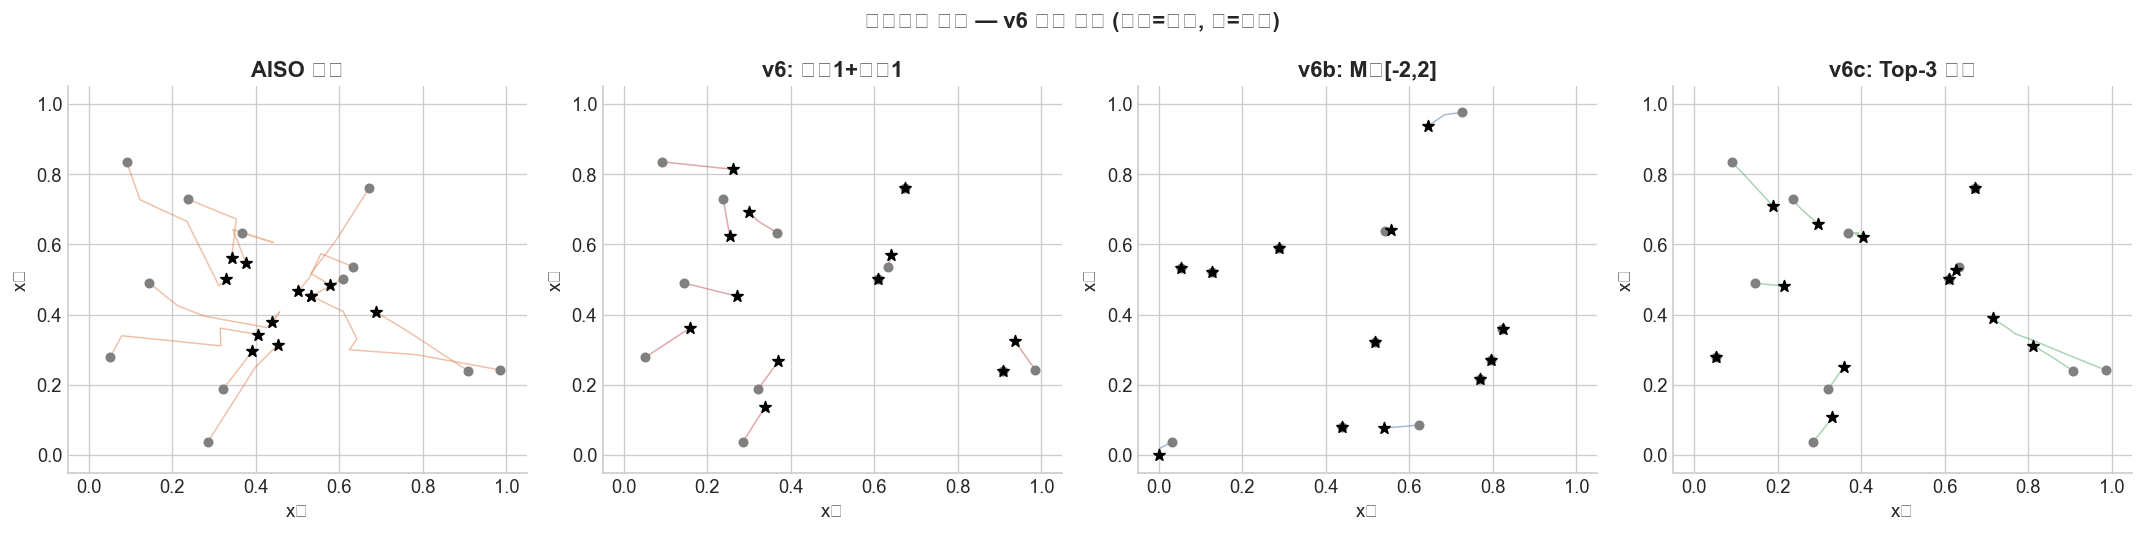

In [4]:
def traj_2d(mode, n_agents=12, n_iter=80, seed=42, alpha=0.3, k=3):
    np.random.seed(seed)
    K2=2; nt=N_TYPES
    M = np.random.uniform(0,2,(nt,nt)) if mode=='orig' else np.random.uniform(-1,2,(nt,nt))
    if mode=='v6b': M = np.random.uniform(-2,2,(nt,nt))
    X = np.random.rand(n_agents,K2)
    W = np.random.dirichlet(np.ones(nt),n_agents)
    f2 = make_ackley()
    pad = lambda x: np.pad(x,(0,K-K2))
    S = np.array([f2(pad(X[i])) for i in range(n_agents)])
    traj=[X.copy()]

    for _ in range(n_iter):
        C = W@M@W.T
        np.fill_diagonal(C,0)
        for i in range(n_agents):
            ci=C[i].copy(); ci[i]=0
            if mode=='orig':
                j=np.random.randint(n_agents)
                while j==i: j=np.random.randint(n_agents)
                c=float(W[i]@M@W[j])
                nX=np.clip(X[i]+0.3*c*(X[j]-X[i]),0,1)
            elif mode in ('v6','v6b'):
                ja=np.argmax(ci); jr=np.argmin(ci)
                ca=float(W[i]@M@W[ja]); cr=float(W[i]@M@W[jr])
                F=ca*(X[ja]-X[i])+cr*(X[jr]-X[i])
                nX=np.clip(X[i]+alpha*F,0,1)
            else:  # v6c
                ta=np.argsort(ci)[-k:]; tr=np.argsort(ci)[:k]
                F=np.zeros(K2)
                for ja in ta: F+=ci[ja]*(X[ja]-X[i])
                for jr in tr: F+=ci[jr]*(X[jr]-X[i])
                F/=(2*k); nX=np.clip(X[i]+alpha*F,0,1)

            ns=f2(pad(nX))
            if ns<S[i]:
                X[i]=nX; S[i]=ns
                if mode=='orig':
                    W[i]=(1-BETA)*W[i]+BETA*W[j]; W[i]/=W[i].sum()
                elif mode in ('v6','v6b'):
                    W[i]=(1-BETA)*W[i]+BETA*W[ja]; W[i]/=W[i].sum()
                else:
                    bja=ta[np.argmax(ci[ta])]
                    W[i]=(1-BETA)*W[i]+BETA*W[bja]; W[i]/=W[i].sum()
        traj.append(X.copy())
    return np.array(traj)

fig,axes=plt.subplots(1,4,figsize=(18,4.5))
configs=[('orig','AISO 원본','#DD8452'),('v6','v6: 인력1+척력1','#C44E52'),
         ('v6b','v6b: M∈[-2,2]','#4C72B0'),('v6c','v6c: Top-3 각각','#55A868')]

for ax,(mode,title,col) in zip(axes,configs):
    tr=traj_2d(mode)
    for a in range(tr.shape[1]):
        xs,ys=tr[:,a,0],tr[:,a,1]
        ax.plot(xs,ys,alpha=0.5,lw=0.9,color=col)
        ax.scatter(xs[0],ys[0],s=25,color='gray',zorder=4)
        ax.scatter(xs[-1],ys[-1],s=50,color='black',zorder=5,marker='*')
    ax.set_xlim(-0.05,1.05); ax.set_ylim(-0.05,1.05)
    ax.set_title(title,fontweight='bold'); ax.set_xlabel('x₁'); ax.set_ylabel('x₂')

plt.suptitle('에이전트 궤도 — v6 삼체 역학 (회색=시작, ★=종료)',fontweight='bold')
plt.tight_layout()
plt.savefig('aiso_v6_trajectories.png',bbox_inches='tight')
plt.show()

## 전체 벤치마크 + 결과


── Sphere ──
  PSO                   1.290 ± 0.916
  AISO                  8.430 ± 2.114  (-553.5%)
  AISO_v6              23.985 ± 7.946  (-1759.3%)
  AISO_v6b            100.663 ± 49.828  (-7703.4%)
  AISO_v6c             17.135 ± 4.127  (-1228.3%)

── Rosenbrock ──
  PSO                 133.143 ± 60.462
  AISO                171.842 ± 52.891  (-29.1%)
  AISO_v6             503.117 ± 196.612  (-277.9%)
  AISO_v6b           3670.043 ± 2295.309  (-2656.5%)
  AISO_v6c            348.343 ± 88.822  (-161.6%)

── Zakharov ──
  PSO                 134.343 ± 31.167
  AISO                 11.279 ± 2.760  (+91.6%)
  AISO_v6              40.016 ± 25.013  (+70.2%)
  AISO_v6b            201.031 ± 92.262  (-49.6%)
  AISO_v6c             22.512 ± 6.425  (+83.2%)

── Dixon-Price ──
  PSO                4260.879 ± 15928.253
  AISO               7683.821 ± 7118.824  (-80.3%)
  AISO_v6           52265.516 ± 39629.223  (-1126.6%)
  AISO_v6b         812138.537 ± 608399.119  (-18960.4%)
  AISO_v6c       

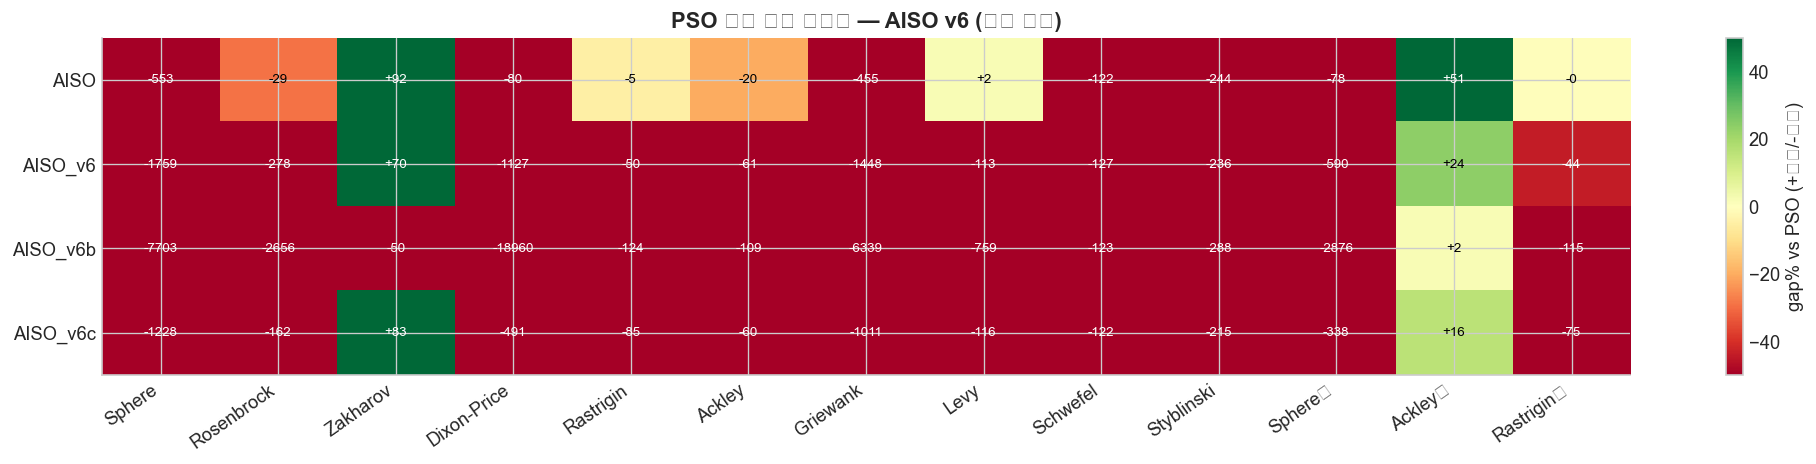

  AISO          :  3/13승 | 전체 -111.0% | 노이즈 -9.2%
  AISO_v6       :  2/13승 | 전체 -441.4% | 노이즈 -203.4%
  AISO_v6b      :  1/13승 | 전체 -3084.7% | 노이즈 -996.3%
  AISO_v6c      :  2/13승 | 전체 -292.5% | 노이즈 -132.2%


In [5]:
all_results = {}
for b in BENCHMARKS:
    fname = b.__name__
    print(f'\n── {fname} ──')
    all_results[fname] = {}
    for aname, afunc in ALGOS.items():
        scores = [afunc(b, K, seed=42+r) for r in range(N_RUNS)]
        all_results[fname][aname] = scores
        m = np.mean(scores)
        if aname != 'PSO':
            pso_m = np.mean(all_results[fname]['PSO'])
            gap = -(m-pso_m)/(abs(pso_m)+1e-8)*100
            print(f'  {aname:<14} {m:>12.3f} ± {np.std(scores):.3f}  ({gap:+.1f}%)')
        else:
            print(f'  {aname:<14} {m:>12.3f} ± {np.std(scores):.3f}')
print('\n✓ 완료!')

# ── 히트맵 ──────────────────────────────────────────────────
fnames     = list(all_results.keys())
anames     = list(ALGOS.keys())
row_labels = [a for a in anames if a != 'PSO']
COLORS     = {'PSO':'#4C72B0','AISO':'#DD8452','AISO_v6':'#C44E52',
              'AISO_v6b':'#4C72B0','AISO_v6c':'#55A868'}

gap_mat = np.zeros((len(row_labels), len(fnames)))
for ri,an in enumerate(row_labels):
    for ci,fn in enumerate(fnames):
        pso_m=np.mean(all_results[fn]['PSO']); ai_m=np.mean(all_results[fn][an])
        gap_mat[ri,ci]=-(ai_m-pso_m)/(abs(pso_m)+1e-8)*100

fig,ax=plt.subplots(figsize=(17,4))
im=ax.imshow(gap_mat,cmap='RdYlGn',aspect='auto',vmin=-50,vmax=50)
plt.colorbar(im,ax=ax,label='gap% vs PSO (+좋음/-나쁨)')
ax.set_xticks(range(len(fnames)))
ax.set_xticklabels([f.replace('_N','★') for f in fnames],rotation=35,ha='right')
ax.set_yticks(range(len(row_labels))); ax.set_yticklabels(row_labels)
ax.set_title('PSO 대비 성능 히트맵 — AISO v6 (삼체 밀당)',fontweight='bold')
for ri in range(len(row_labels)):
    for ci in range(len(fnames)):
        v=gap_mat[ri,ci]
        ax.text(ci,ri,f'{v:+.0f}',ha='center',va='center',fontsize=8,
                color='black' if abs(v)<30 else 'white')
plt.tight_layout()
plt.savefig('aiso_v6_heatmap.png',bbox_inches='tight')
plt.show()

# ── 승수 요약 ────────────────────────────────────────────────
standard_fns=[f for f in fnames if '_N' not in f]
noisy_fns   =[f for f in fnames if '_N' in f]
print('='*60)
for an in row_labels:
    wins =sum(np.mean(all_results[fn][an])<np.mean(all_results[fn]['PSO']) for fn in fnames)
    g_all=np.mean([-(np.mean(all_results[fn][an])-np.mean(all_results[fn]['PSO']))/(abs(np.mean(all_results[fn]['PSO']))+1e-8)*100 for fn in fnames])
    g_n  =np.mean([-(np.mean(all_results[fn][an])-np.mean(all_results[fn]['PSO']))/(abs(np.mean(all_results[fn]['PSO']))+1e-8)*100 for fn in noisy_fns])
    print(f'  {an:<14}: {wins:2d}/13승 | 전체 {g_all:+.1f}% | 노이즈 {g_n:+.1f}%')
print('='*60)

## W 업데이트 전략 실험

In [6]:
# 베이스: v6c 구조 (Top-3 인력 + Top-3 척력, M∈[-1,2])
# W 업데이트 전략만 바꿔서 비교
#
# W_FROZEN   : W 고정 (BETA=0) — 타입 불변, c_ij 관계 유지
# W_ATTRACT  : 현재 방식 — 인력 파트너 흡수
# W_REPEL    : 척력 파트너에서 멀어지기 — W[i] -= BETA*(W[jr]-W[i])
# W_BEST     : 군내 최고 에이전트 타입 흡수 (성과 기반)
# W_DIVERSE  : 개선 시 W에 작은 랜덤 노이즈 추가 (다양성 유지)

def run_v6_w(f, K, seed, w_mode='frozen', n_iter=N_ITER, n_agents=N_AGENTS,
             n_types=N_TYPES, alpha=0.15, k=3):
    np.random.seed(seed)
    M = np.random.uniform(-1, 2, (n_types, n_types))
    X = np.random.rand(n_agents, K)
    W = np.random.dirichlet(np.ones(n_types), n_agents)
    S = np.array([f(X[i]) for i in range(n_agents)])
    bS = S.min()

    for _ in range(n_iter):
        C = W @ M @ W.T
        np.fill_diagonal(C, 0)
        best_agent = np.argmin(S)   # 현재 최고 에이전트 (W_BEST용)

        for i in range(n_agents):
            ci = C[i].copy(); ci[i] = 0
            top_a = np.argsort(ci)[-k:]   # 상위 k 인력
            top_r = np.argsort(ci)[:k]    # 상위 k 척력

            F = np.zeros(K)
            for ja in top_a: F += ci[ja] * (X[ja] - X[i])
            for jr in top_r: F += ci[jr] * (X[jr] - X[i])
            F /= (2 * k)

            nX = np.clip(X[i] + alpha * F, 0, 1)
            ns = f(nX)

            if ns < S[i]:
                X[i] = nX; S[i] = ns

                if w_mode == 'frozen':
                    pass  # W 변경 없음

                elif w_mode == 'attract':
                    # 현재 방식: 가장 강한 인력 파트너 흡수
                    ja_best = top_a[np.argmax(ci[top_a])]
                    W[i] = (1-BETA)*W[i] + BETA*W[ja_best]
                    W[i] /= W[i].sum()

                elif w_mode == 'repel':
                    # 척력 파트너에서 멀어지기
                    jr_worst = top_r[np.argmin(ci[top_r])]
                    W[i] = W[i] - BETA * (W[jr_worst] - W[i])
                    W[i] = np.clip(W[i], 1e-8, None)
                    W[i] /= W[i].sum()

                elif w_mode == 'best':
                    # 군내 최고 성과 에이전트 타입 흡수
                    W[i] = (1-BETA)*W[i] + BETA*W[best_agent]
                    W[i] /= W[i].sum()

                elif w_mode == 'diverse':
                    # 개선 시 작은 랜덤 노이즈 → 타입 다양성 유지
                    noise = np.random.dirichlet(np.ones(n_types)) * BETA
                    W[i] = (1-BETA)*W[i] + noise
                    W[i] /= W[i].sum()

        if S.min() < bS: bS = S.min()
    return bS


W_MODES = {
    'W_frozen'  : 'frozen',
    'W_attract' : 'attract',   # 원래 방식
    'W_repel'   : 'repel',
    'W_best'    : 'best',
    'W_diverse' : 'diverse',
}

# 3개 함수로 빠른 비교
QUICK_FNS = [make_rastrigin(), make_ackley(), make_griewank(),
             make_schwefel(), make_sphere(), make_rosenbrock(),
             make_rastrigin(NOISE_SD), make_ackley(NOISE_SD)]

w_results = {}
for b in QUICK_FNS:
    fname = b.__name__
    print(f'\n── {fname} ──')
    w_results[fname] = {}
    pso_m = np.mean([run_pso(b, K, seed=42+r) for r in range(N_RUNS)])
    w_results[fname]['PSO'] = pso_m
    for wname, wmode in W_MODES.items():
        scores = [run_v6_w(b, K, seed=42+r, w_mode=wmode) for r in range(N_RUNS)]
        m = np.mean(scores)
        w_results[fname][wname] = m
        gap = -(m-pso_m)/(abs(pso_m)+1e-8)*100
        print(f'  {wname:<14} {m:>12.3f}  ({gap:+.1f}% vs PSO)')

print('\n✓ 완료!')


── Rastrigin ──
  W_frozen            341.290  (-96.3% vs PSO)
  W_attract           321.773  (-85.1% vs PSO)
  W_repel             345.774  (-98.9% vs PSO)
  W_best              335.153  (-92.8% vs PSO)
  W_diverse           329.784  (-89.7% vs PSO)

── Ackley ──
  W_frozen             15.801  (-68.2% vs PSO)
  W_attract            15.003  (-59.7% vs PSO)
  W_repel              15.731  (-67.4% vs PSO)
  W_best               15.213  (-61.9% vs PSO)
  W_diverse            15.118  (-60.9% vs PSO)

── Griewank ──
  W_frozen             58.075  (-929.0% vs PSO)
  W_attract            62.686  (-1010.7% vs PSO)
  W_repel              58.371  (-934.2% vs PSO)
  W_best               66.052  (-1070.3% vs PSO)
  W_diverse            49.715  (-780.8% vs PSO)

── Schwefel ──
  W_frozen           9894.698  (-122.1% vs PSO)
  W_attract          9890.966  (-122.1% vs PSO)
  W_repel            9894.698  (-122.1% vs PSO)
  W_best             9902.837  (-122.3% vs PSO)
  W_diverse          9901.894  (-

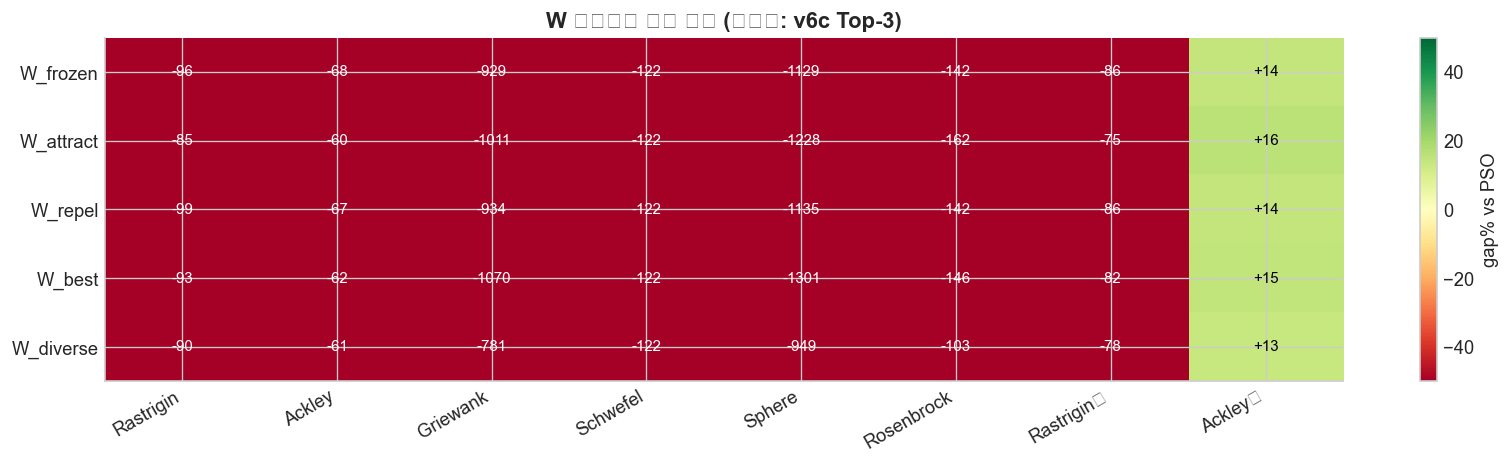

  W 전략별 PSO 대비 승수 및 평균 gap%
  W_frozen      : 1/8승  평균 -319.8% ←
  W_attract     : 1/8승  평균 -340.8% ←
  W_repel       : 1/8승  평균 -321.5% ←
  W_best        : 1/8승  평균 -357.6% ←
  W_diverse     : 1/8승  평균 -271.3% ←


In [7]:
# W 전략 비교 히트맵
wfnames    = list(w_results.keys())
wnames_row = list(W_MODES.keys())

gap_w = np.zeros((len(wnames_row), len(wfnames)))
for ri, wn in enumerate(wnames_row):
    for ci, fn in enumerate(wfnames):
        pso_m = w_results[fn]['PSO']
        ai_m  = w_results[fn][wn]
        gap_w[ri, ci] = -(ai_m - pso_m) / (abs(pso_m)+1e-8) * 100

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(gap_w, cmap='RdYlGn', aspect='auto', vmin=-50, vmax=50)
plt.colorbar(im, ax=ax, label='gap% vs PSO')
ax.set_xticks(range(len(wfnames)))
ax.set_xticklabels([f.replace('_N','★') for f in wfnames], rotation=30, ha='right')
ax.set_yticks(range(len(wnames_row))); ax.set_yticklabels(wnames_row)
ax.set_title('W 업데이트 전략 비교 (베이스: v6c Top-3)', fontweight='bold')
for ri in range(len(wnames_row)):
    for ci in range(len(wfnames)):
        v = gap_w[ri, ci]
        ax.text(ci, ri, f'{v:+.0f}', ha='center', va='center', fontsize=9,
                color='black' if abs(v)<30 else 'white')
plt.tight_layout()
plt.savefig('aiso_v6_w_heatmap.png', bbox_inches='tight')
plt.show()

# 전략별 평균 승수
print('='*50)
print('  W 전략별 PSO 대비 승수 및 평균 gap%')
print('='*50)
for wn in wnames_row:
    wins = sum(w_results[fn][wn] < w_results[fn]['PSO'] for fn in wfnames)
    g    = np.mean([-(w_results[fn][wn]-w_results[fn]['PSO'])/(abs(w_results[fn]['PSO'])+1e-8)*100 for fn in wfnames])
    marker = ' ←' if wins == max(sum(w_results[fn][ww] < w_results[fn]['PSO'] for fn in wfnames) for ww in wnames_row) else ''
    print(f'  {wn:<14}: {wins}/{len(wfnames)}승  평균 {g:+.1f}%{marker}')
print('='*50)